In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import mokapot

import pyXLMS
from pyXLMS.data import create_csm
from pyXLMS.parser.util import format_sequence
from pyXLMS.parser.util import get_bool_from_value

from typing import List
from typing import Dict
from typing import Any
from typing import Literal

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14492 entries, 0 to 14491
Data columns (total 73 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   R.FileName                            14492 non-null  object 
 1   R.Condition                           14492 non-null  object 
 2   PG.ProteinNames                       14492 non-null  object 
 3   PG.Cscore                             3623 non-null   float64
 4   EG.Library                            14492 non-null  object 
 5   EG.PrecursorId                        14492 non-null  object 
 6   EG.Cscore                             14492 non-null  float64
 7   FG.Charge                             14492 non-null  int64  
 8   FG.Comment                            14492 non-null  object 
 9   F.CalibratedMz                        14492 non-null  float64
 10  PG.Pvalue                             14492 non-null  float64
 11  PG.PValue (Run-

In [4]:
df["MP.Target"] = df.apply(lambda row: not (row["PP.IsDecoyA"] or row["PP.IsDecoyB"]), axis=1)

In [5]:
df["MP.Peptide"] = df.apply(lambda row: row["PP.PeptideA"]+row["PP.PeptideB"], axis=1)

In [6]:
df["MP.Protein"] = df.apply(lambda row: ";".join(set(row["PP.ProteinA"].split(";")) | set(row["PP.ProteinB"].split(";"))), axis=1)

In [7]:
df.dropna(axis=1, inplace=True)

In [8]:
potential_rescoring_features = [  
    "PG.Cscore",  
    "EG.Cscore",
    "FG.Charge",    
    "PG.Pvalue",
    "PG.PValue (Run-Wise)",
    "PG.Qvalue",
    "PG.QValue (Run-Wise)",
    "EG.GlobalPrecursorQvalue",
    "EG.MaxChannelQvalue",
    "EG.MinChannelQvalue",
    "EG.Qvalue",
    "EG.InSourceFragmentationParentQvalue",
    "EG.AvgProfileQvalue",
    "EG.MaxProfileQvalue",
    "EG.MinProfileQvalue",
    "EG.PercentileQvalue",
    "FG.Qvalue",
    "PP.MatchedIonsA",  
    "PP.TotalIonsA", 
    "PP.MatchedIonsB",  
    "PP.TotalIonsB", 
    "PP.RelativeMatchScoreA",
    "PP.RelativeMatchScoreB",
    "PP.PartialCscoreA",
    "PP.PartialCscoreB",
    "PP.CompositeRelativeMatchScore",
    "PP.CompositePartialCscore",          
    "PP.IsDecoyA",   
    "PP.IsDecoyB",    
    "PP.SequenceCoverageNTermAlpha",
    "PP.SequenceCoverageNTermBeta",
    "PP.SequenceCoverageNTermFull",
    "PP.SequenceCoverageCTermAlpha",
    "PP.SequenceCoverageCTermBeta",
    "PP.SequenceCoverageCTermFull",
    "PP.SequenceCoverageAlpha",
    "PP.SequenceCoverageBeta",
    "PP.SequenceCoverageFull",
    "PP.UniScoreAlpha",  
    "PP.UniScoreBeta", 
    "PP.UniScoreFull",
    "PP.PepLenAlpha",  
    "PP.PepLenBeta",  
    "PP.NumberCrosslinkFragmentsAlpha", 
    "PP.NumberCrosslinkFragmentsBeta",  
    "PP.NumberCrosslinkFragmentsFull",  
    "PP.NormalizedCrosslinkFragmentsAlpha",
    "PP.NormalizedCrosslinkFragmentsBeta",
    "PP.NormalizedCrosslinkFragmentsFull",
]

In [9]:
rescoring_features = [feature for feature in potential_rescoring_features if feature in df]

In [10]:
# https://mokapot.readthedocs.io/en/latest/api/dataset.html
psms = mokapot.dataset.LinearPsmDataset(
    psms=df,
    target_column="MP.Target",
    spectrum_columns=["R.FileName", "R.Condition", "PP.PseudoScanNumber"],
    peptide_column="MP.Peptide",
    protein_column="MP.Protein",
    feature_columns=rescoring_features,
    copy_data=True,
    rng=1337,
)

In [11]:
models, scores = mokapot.brew([psms])

Model training failed on 3/3. Setting scores to zero.
Learned model did not improve over the best feature. Now scoring by the best feature for each collection of PSMs.


In [12]:
df["Mokapot Score"] = scores[0]

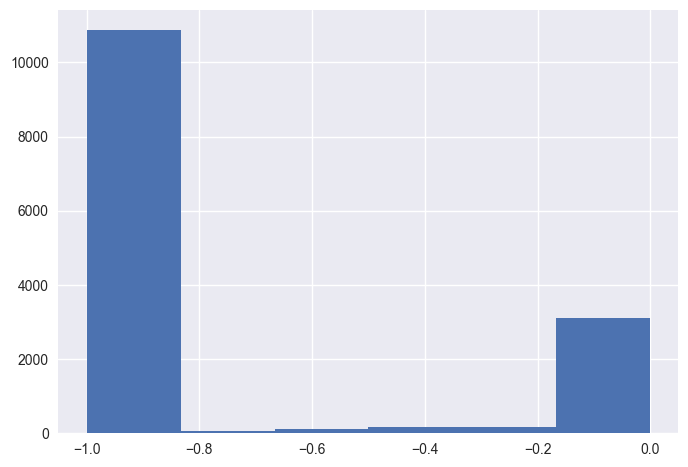

In [13]:
df["Mokapot Score"].hist(bins=6);

In [14]:
conf = mokapot.confidence.assign_confidence([psms], scores)

C:\Users\Micha\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\tabular_data\csv.py:107: UserWarning: CSV file targets.psms.csv exists, but will be overwritten.
  warnings.warn(
C:\Users\Micha\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\tabular_data\csv.py:107: UserWarning: CSV file targets.mp.peptides.csv exists, but will be overwritten.
  warnings.warn(
C:\Users\Micha\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\tabular_data\csv.py:107: UserWarning: CSV file scores_metadata_0.csv exists, but will be overwritten.
  warnings.warn(
C:\Users\Micha\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\triqler\qvality.py:267: RuntimeWarning: overflow encountered in dot
  M = R + Q.T.dot(aWiQ)
C:\Users\Micha\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\triqler\qvality.py:267: R

In [39]:
def read_csms(
    df: pd.DataFrame,
) -> List[Dict[str, Any]]:
    csms = list()
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Reading CSMs..."):
        score_a = None
        score_b = None
        score_csm = float(row["Mokapot Score"])
        csm = create_csm(
            peptide_a=format_sequence(row["PP.PeptideA"]),
            modifications_a=None,
            xl_position_peptide_a=int(row["PP.CrosslinkPositionPeptideA"]),
            proteins_a=str(row["PP.ProteinA"]).split(";"),
            xl_position_proteins_a=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinA"]).split(";")
            ],
            pep_position_proteins_a=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinA"]).split(";")
            ],
            score_a=score_a,
            decoy_a=get_bool_from_value(row["PP.IsDecoyA"]),
            peptide_b=format_sequence(row["PP.PeptideB"]),
            modifications_b=None,
            xl_position_peptide_b=int(row["PP.CrosslinkPositionPeptideB"]),
            proteins_b=str(row["PP.ProteinB"]).split(";"),
            xl_position_proteins_b=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinB"]).split(";")
            ],
            pep_position_proteins_b=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinB"]).split(";")
            ],
            score_b=score_b,
            decoy_b=get_bool_from_value(row["PP.IsDecoyB"]),
            score=score_csm,
            spectrum_file=f"{row['R.Condition'].strip()}:{row['R.FileName'].strip()}",
            scan_nr=int(row["PP.PseudoScanNumber"]),
            charge=int(row["FG.Charge"]),
            rt=None,
            im_cv=None,
        )
        csms.append(csm)
    return csms


def pipeline(csms: List[Dict[str, Any]], fdr=0.01) -> List[Dict[str, Any]]:
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr=fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [40]:
csms = read_csms(df)

Reading CSMs...: 100%|██████████████████████████████████████████████████████████████████████████████████████| 14492/14492 [00:00<00:00, 23568.89it/s]


In [41]:
validated_targets = pipeline(csms)

Iterating over scores for FDR calculation...:  75%|██████████████████████████████████████████▊              | 10869/14492 [00:00<00:00, 83730.16it/s]


In [42]:
len(validated_targets)

3623